# EEG Quantum Neural Network - Data Pipeline & Architecture Visualization

## Comprehensive Guide to Understanding the Complete System

This notebook visualizes every stage of the EEG emotion recognition pipeline with clear diagrams and explanations.

## Section 1: Import Libraries and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
import pandas as pd
from matplotlib.gridspec import GridSpec

# Set visualization styles
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'

# Color scheme
COLORS = {
    'raw': '#FF6B6B',      # Red for raw data
    'process': '#4ECDC4',  # Teal for processing
    'model': '#45B7D1',    # Blue for model
    'quantum': '#96CEB4',  # Green for quantum
    'output': '#FFEAA7'    # Yellow for output
}

print('✓ All libraries imported successfully')
print('✓ Visualization styles configured')

✓ All libraries imported successfully
✓ Visualization styles configured


## Section 2: Environment Setup Overview

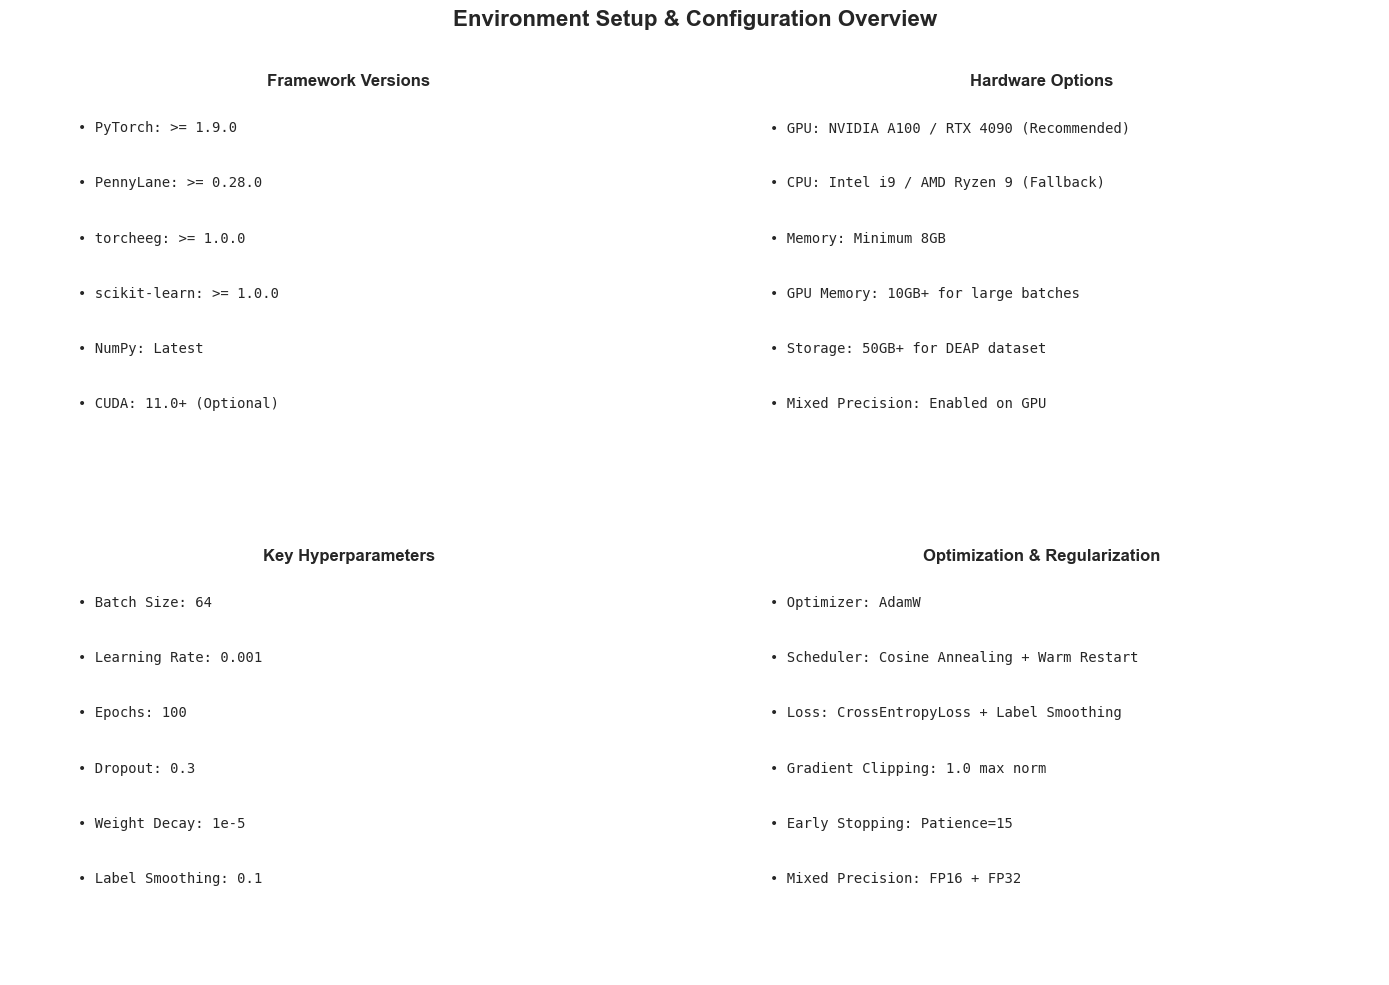

✓ Environment configuration visualized


In [2]:
# Create environment configuration summary
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Environment Setup & Configuration Overview', fontsize=16, fontweight='bold', y=0.98)

# 1. Framework versions
ax1.axis('off')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.text(5, 9, 'Framework Versions', ha='center', fontsize=12, fontweight='bold')

versions = [
    'PyTorch: >= 1.9.0',
    'PennyLane: >= 0.28.0',
    'torcheeg: >= 1.0.0',
    'scikit-learn: >= 1.0.0',
    'NumPy: Latest',
    'CUDA: 11.0+ (Optional)'
]

for i, version in enumerate(versions):
    ax1.text(1, 8 - i*1.2, f'• {version}', fontsize=10, family='monospace')

# 2. Hardware specifications
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.text(5, 9, 'Hardware Options', ha='center', fontsize=12, fontweight='bold')

hardware = [
    'GPU: NVIDIA A100 / RTX 4090 (Recommended)',
    'CPU: Intel i9 / AMD Ryzen 9 (Fallback)',
    'Memory: Minimum 8GB',
    'GPU Memory: 10GB+ for large batches',
    'Storage: 50GB+ for DEAP dataset',
    'Mixed Precision: Enabled on GPU'
]

for i, hw in enumerate(hardware):
    ax2.text(1, 8 - i*1.2, f'• {hw}', fontsize=10, family='monospace')

# 3. Training configuration
ax3.axis('off')
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.text(5, 9, 'Key Hyperparameters', ha='center', fontsize=12, fontweight='bold')

config_items = [
    ('Batch Size', '64'),
    ('Learning Rate', '0.001'),
    ('Epochs', '100'),
    ('Dropout', '0.3'),
    ('Weight Decay', '1e-5'),
    ('Label Smoothing', '0.1')
]

for i, (param, value) in enumerate(config_items):
    ax3.text(1, 8 - i*1.2, f'• {param}: {value}', fontsize=10, family='monospace')

# 4. Optimization methods
ax4.axis('off')
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 10)
ax4.text(5, 9, 'Optimization & Regularization', ha='center', fontsize=12, fontweight='bold')

opt_items = [
    'Optimizer: AdamW',
    'Scheduler: Cosine Annealing + Warm Restart',
    'Loss: CrossEntropyLoss + Label Smoothing',
    'Gradient Clipping: 1.0 max norm',
    'Early Stopping: Patience=15',
    'Mixed Precision: FP16 + FP32'
]

for i, opt in enumerate(opt_items):
    ax4.text(1, 8 - i*1.2, f'• {opt}', fontsize=10, family='monospace')

plt.tight_layout()
plt.show()

print('✓ Environment configuration visualized')

## Section 3: DEAP Dataset Overview

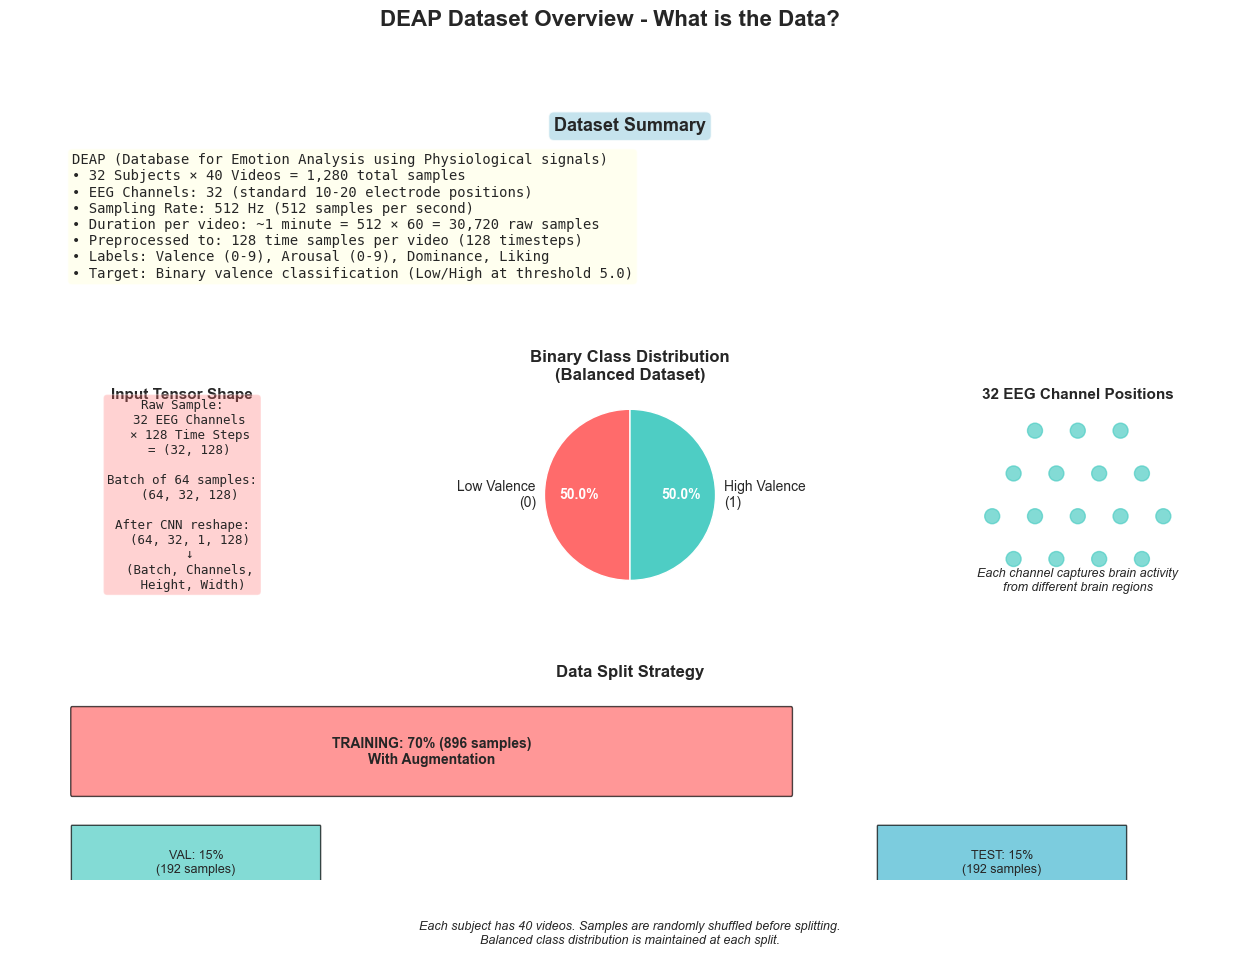

✓ Dataset overview created


In [3]:
# Create comprehensive dataset overview
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
fig.suptitle('DEAP Dataset Overview - What is the Data?', fontsize=16, fontweight='bold')

# 1. Dataset statistics
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')
ax1.text(0.5, 0.9, 'Dataset Summary', ha='center', fontsize=13, fontweight='bold', 
         transform=ax1.transAxes, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

stats_text = '''DEAP (Database for Emotion Analysis using Physiological signals)
• 32 Subjects × 40 Videos = 1,280 total samples
• EEG Channels: 32 (standard 10-20 electrode positions)
• Sampling Rate: 512 Hz (512 samples per second)
• Duration per video: ~1 minute = 512 × 60 = 30,720 raw samples
• Preprocessed to: 128 time samples per video (128 timesteps)
• Labels: Valence (0-9), Arousal (0-9), Dominance, Liking
• Target: Binary valence classification (Low/High at threshold 5.0)'''

ax1.text(0.05, 0.5, stats_text, ha='left', va='center', fontsize=10, family='monospace',
         transform=ax1.transAxes, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# 2. Input shape explanation
ax2 = fig.add_subplot(gs[1, 0])
ax2.axis('off')
ax2.text(0.5, 0.95, 'Input Tensor Shape', ha='center', fontsize=11, fontweight='bold',
         transform=ax2.transAxes)

input_shape_text = '''Raw Sample:
  32 EEG Channels
  × 128 Time Steps
  = (32, 128)

Batch of 64 samples:
  (64, 32, 128)

After CNN reshape:
  (64, 32, 1, 128)
  ↓
  (Batch, Channels,
   Height, Width)'''

ax2.text(0.5, 0.5, input_shape_text, ha='center', va='center', fontsize=9, family='monospace',
         transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor=COLORS['raw'], alpha=0.3))

# 3. Class distribution
ax3 = fig.add_subplot(gs[1, 1])
classes = ['Low Valence\n(0)', 'High Valence\n(1)']
counts = [640, 640]  # Balanced dataset
colors_dist = ['#FF6B6B', '#4ECDC4']
wedges, texts, autotexts = ax3.pie(counts, labels=classes, autopct='%1.1f%%',
                                     colors=colors_dist, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax3.set_title('Binary Class Distribution\n(Balanced Dataset)', fontweight='bold')

# 4. EEG channel grid
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_xlim(-1, 9)
ax4.set_ylim(-1, 9)
ax4.set_aspect('equal')
ax4.axis('off')
ax4.text(4, 8.5, '32 EEG Channel Positions', ha='center', fontsize=11, fontweight='bold')

# Simplified 10-20 electrode positions grid
positions = [
    (2, 7), (4, 7), (6, 7),  # Frontal
    (1, 5), (3, 5), (5, 5), (7, 5),  # Central
    (0, 3), (2, 3), (4, 3), (6, 3), (8, 3),  # Temporal
    (1, 1), (3, 1), (5, 1), (7, 1)  # Occipital
]

for x, y in positions:
    circle = plt.Circle((x, y), 0.35, color=COLORS['process'], alpha=0.7)
    ax4.add_patch(circle)

ax4.text(4, -0.5, 'Each channel captures brain activity\nfrom different brain regions', 
         ha='center', fontsize=9, style='italic')

# 5. Train/Val/Test split
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
ax5.text(0.5, 0.95, 'Data Split Strategy', ha='center', fontsize=12, fontweight='bold',
         transform=ax5.transAxes)

# Split visualization
ax5.set_xlim(0, 100)
ax5.set_ylim(0, 10)

# Train split
rect_train = FancyBboxPatch((5, 4), 58, 4, boxstyle='round,pad=0.1', 
                            edgecolor='black', facecolor=COLORS['raw'], alpha=0.7)
ax5.add_patch(rect_train)
ax5.text(34, 6, 'TRAINING: 70% (896 samples)\nWith Augmentation', ha='center', va='center', fontweight='bold')

# Val split
rect_val = FancyBboxPatch((5, -0.5), 20, 3, boxstyle='round,pad=0.05',
                          edgecolor='black', facecolor=COLORS['process'], alpha=0.7)
ax5.add_patch(rect_val)
ax5.text(15, 0.8, 'VAL: 15%\n(192 samples)', ha='center', va='center', fontsize=9)

# Test split
rect_test = FancyBboxPatch((70, -0.5), 20, 3, boxstyle='round,pad=0.05',
                           edgecolor='black', facecolor=COLORS['model'], alpha=0.7)
ax5.add_patch(rect_test)
ax5.text(80, 0.8, 'TEST: 15%\n(192 samples)', ha='center', va='center', fontsize=9)

ax5.text(50, -3, 'Each subject has 40 videos. Samples are randomly shuffled before splitting.\nBalanced class distribution is maintained at each split.', 
         ha='center', fontsize=9, style='italic')

plt.show()

print('✓ Dataset overview created')

## Section 4: Data Transformation Pipeline - Step-by-Step

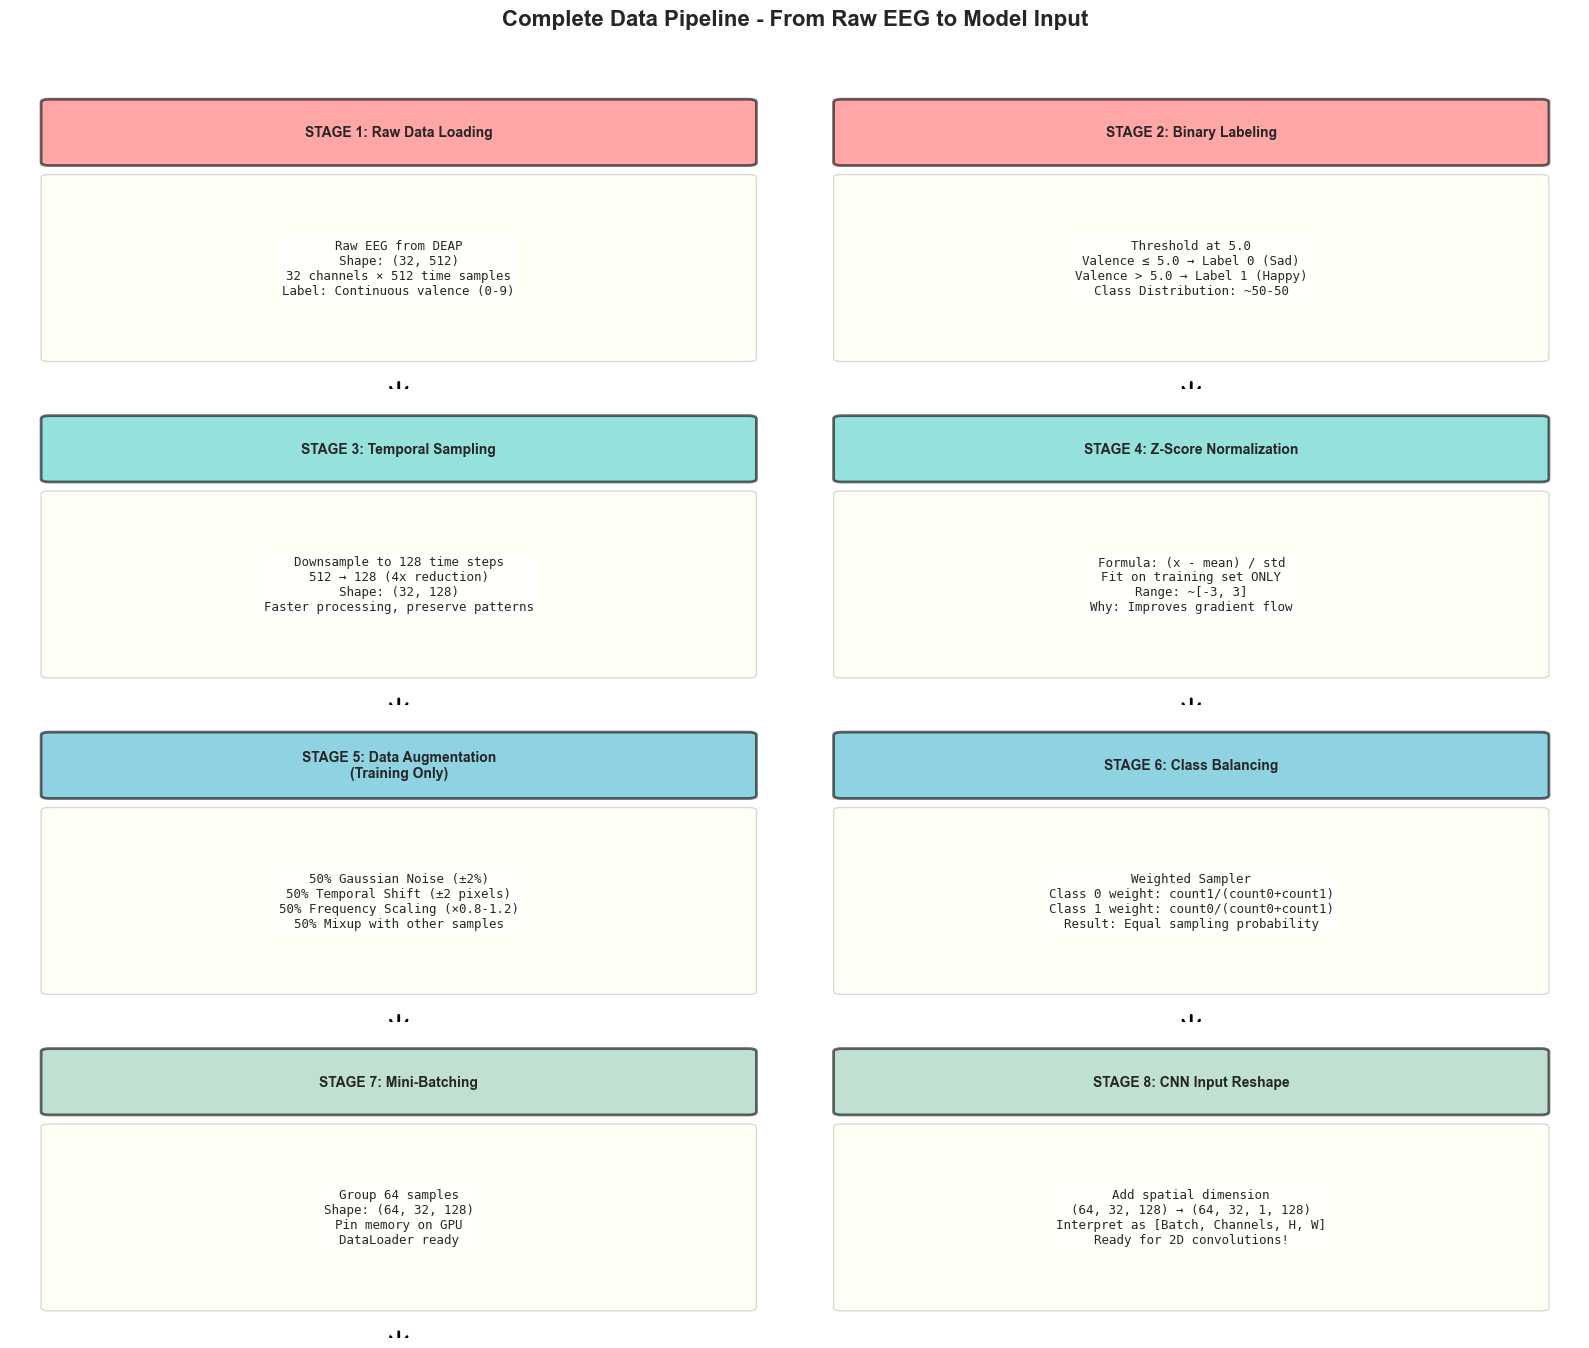

✓ Complete data pipeline visualized


In [4]:
# Detailed pipeline visualization
fig = plt.figure(figsize=(16, 14))

# Main title
fig.suptitle('Complete Data Pipeline - From Raw EEG to Model Input', fontsize=16, fontweight='bold', y=0.98)

# Create subplots for each stage
stages = [
    ('STAGE 1: Raw Data Loading', 'Raw EEG from DEAP\nShape: (32, 512)\n32 channels × 512 time samples\nLabel: Continuous valence (0-9)', COLORS['raw']),
    ('STAGE 2: Binary Labeling', 'Threshold at 5.0\nValence ≤ 5.0 → Label 0 (Sad)\nValence > 5.0 → Label 1 (Happy)\nClass Distribution: ~50-50', COLORS['raw']),
    ('STAGE 3: Temporal Sampling', 'Downsample to 128 time steps\n512 → 128 (4x reduction)\nShape: (32, 128)\nFaster processing, preserve patterns', COLORS['process']),
    ('STAGE 4: Z-Score Normalization', 'Formula: (x - mean) / std\nFit on training set ONLY\nRange: ~[-3, 3]\nWhy: Improves gradient flow', COLORS['process']),
    ('STAGE 5: Data Augmentation\n(Training Only)', '50% Gaussian Noise (±2%)\n50% Temporal Shift (±2 pixels)\n50% Frequency Scaling (×0.8-1.2)\n50% Mixup with other samples', COLORS['model']),
    ('STAGE 6: Class Balancing', 'Weighted Sampler\nClass 0 weight: count1/(count0+count1)\nClass 1 weight: count0/(count0+count1)\nResult: Equal sampling probability', COLORS['model']),
    ('STAGE 7: Mini-Batching', 'Group 64 samples\nShape: (64, 32, 128)\nPin memory on GPU\nDataLoader ready', COLORS['quantum']),
    ('STAGE 8: CNN Input Reshape', 'Add spatial dimension\n(64, 32, 128) → (64, 32, 1, 128)\nInterpret as [Batch, Channels, H, W]\nReady for 2D convolutions!', COLORS['quantum'])
]

# Draw pipeline
for i, (title, description, color) in enumerate(stages):
    ax = plt.subplot(4, 2, i + 1)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Title box
    rect = FancyBboxPatch((0.5, 7.5), 9, 2, boxstyle='round,pad=0.1',
                          edgecolor='black', facecolor=color, alpha=0.6, linewidth=2)
    ax.add_patch(rect)
    ax.text(5, 8.5, title, ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Description box
    rect2 = FancyBboxPatch((0.5, 1), 9, 6, boxstyle='round,pad=0.1',
                           edgecolor='gray', facecolor='lightyellow', alpha=0.3)
    ax.add_patch(rect2)
    ax.text(5, 4, description, ha='center', va='center', fontsize=9, family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Arrow for next stage
    if i < len(stages) - 1:
        arrow = FancyArrowPatch((5, 0.3), (5, -0.7),
                               arrowstyle='->', mutation_scale=30, color='black', linewidth=2)
        ax.add_patch(arrow)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

print('✓ Complete data pipeline visualized')

## Section 5: Augmentation Techniques - What Happens During Training?

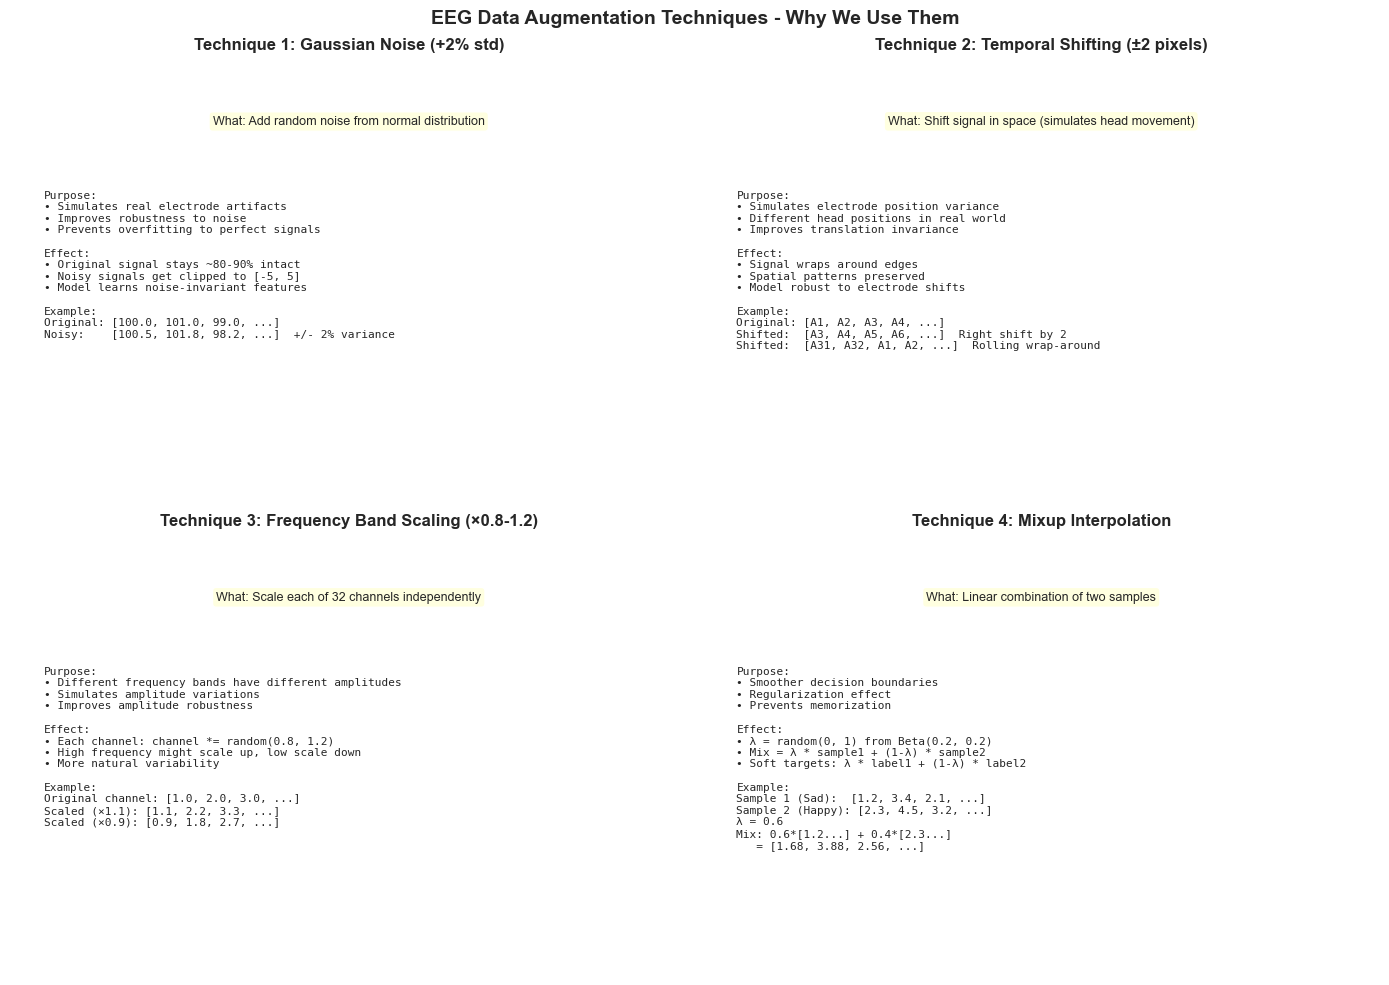

✓ Augmentation techniques visualized


In [5]:
# Augmentation techniques explanation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EEG Data Augmentation Techniques - Why We Use Them', fontsize=14, fontweight='bold')

# 1. Gaussian Noise
ax = axes[0, 0]
ax.set_title('Technique 1: Gaussian Noise (+2% std)', fontweight='bold')
ax.text(0.5, 0.85, 'What: Add random noise from normal distribution', ha='center', transform=ax.transAxes,
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax.text(0.05, 0.7, '''Purpose:
• Simulates real electrode artifacts
• Improves robustness to noise
• Prevents overfitting to perfect signals

Effect:
• Original signal stays ~80-90% intact
• Noisy signals get clipped to [-5, 5]
• Model learns noise-invariant features

Example:
Original: [100.0, 101.0, 99.0, ...]
Noisy:    [100.5, 101.8, 98.2, ...]  +/- 2% variance''', 
        ha='left', va='top', fontsize=8, family='monospace', transform=ax.transAxes)
ax.axis('off')

# 2. Temporal Shift
ax = axes[0, 1]
ax.set_title('Technique 2: Temporal Shifting (±2 pixels)', fontweight='bold')
ax.text(0.5, 0.85, 'What: Shift signal in space (simulates head movement)', ha='center', transform=ax.transAxes,
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax.text(0.05, 0.7, '''Purpose:
• Simulates electrode position variance
• Different head positions in real world
• Improves translation invariance

Effect:
• Signal wraps around edges
• Spatial patterns preserved
• Model robust to electrode shifts

Example:
Original: [A1, A2, A3, A4, ...]
Shifted:  [A3, A4, A5, A6, ...]  Right shift by 2
Shifted:  [A31, A32, A1, A2, ...]  Rolling wrap-around''', 
        ha='left', va='top', fontsize=8, family='monospace', transform=ax.transAxes)
ax.axis('off')

# 3. Frequency Band Scaling
ax = axes[1, 0]
ax.set_title('Technique 3: Frequency Band Scaling (×0.8-1.2)', fontweight='bold')
ax.text(0.5, 0.85, 'What: Scale each of 32 channels independently', ha='center', transform=ax.transAxes,
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax.text(0.05, 0.7, '''Purpose:
• Different frequency bands have different amplitudes
• Simulates amplitude variations
• Improves amplitude robustness

Effect:
• Each channel: channel *= random(0.8, 1.2)
• High frequency might scale up, low scale down
• More natural variability

Example:
Original channel: [1.0, 2.0, 3.0, ...]
Scaled (×1.1): [1.1, 2.2, 3.3, ...]
Scaled (×0.9): [0.9, 1.8, 2.7, ...]''', 
        ha='left', va='top', fontsize=8, family='monospace', transform=ax.transAxes)
ax.axis('off')

# 4. Mixup
ax = axes[1, 1]
ax.set_title('Technique 4: Mixup Interpolation', fontweight='bold')
ax.text(0.5, 0.85, 'What: Linear combination of two samples', ha='center', transform=ax.transAxes,
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax.text(0.05, 0.7, '''Purpose:
• Smoother decision boundaries
• Regularization effect
• Prevents memorization

Effect:
• λ = random(0, 1) from Beta(0.2, 0.2)
• Mix = λ * sample1 + (1-λ) * sample2
• Soft targets: λ * label1 + (1-λ) * label2

Example:
Sample 1 (Sad):  [1.2, 3.4, 2.1, ...]
Sample 2 (Happy): [2.3, 4.5, 3.2, ...]
λ = 0.6
Mix: 0.6*[1.2...] + 0.4*[2.3...]
   = [1.68, 3.88, 2.56, ...]''', 
        ha='left', va='top', fontsize=8, family='monospace', transform=ax.transAxes)
ax.axis('off')

plt.tight_layout()
plt.show()

print('✓ Augmentation techniques visualized')

## 6b. Quantum Circuit Architecture
Visual representation of the 4-qubit parameterized quantum circuit with 2 layers

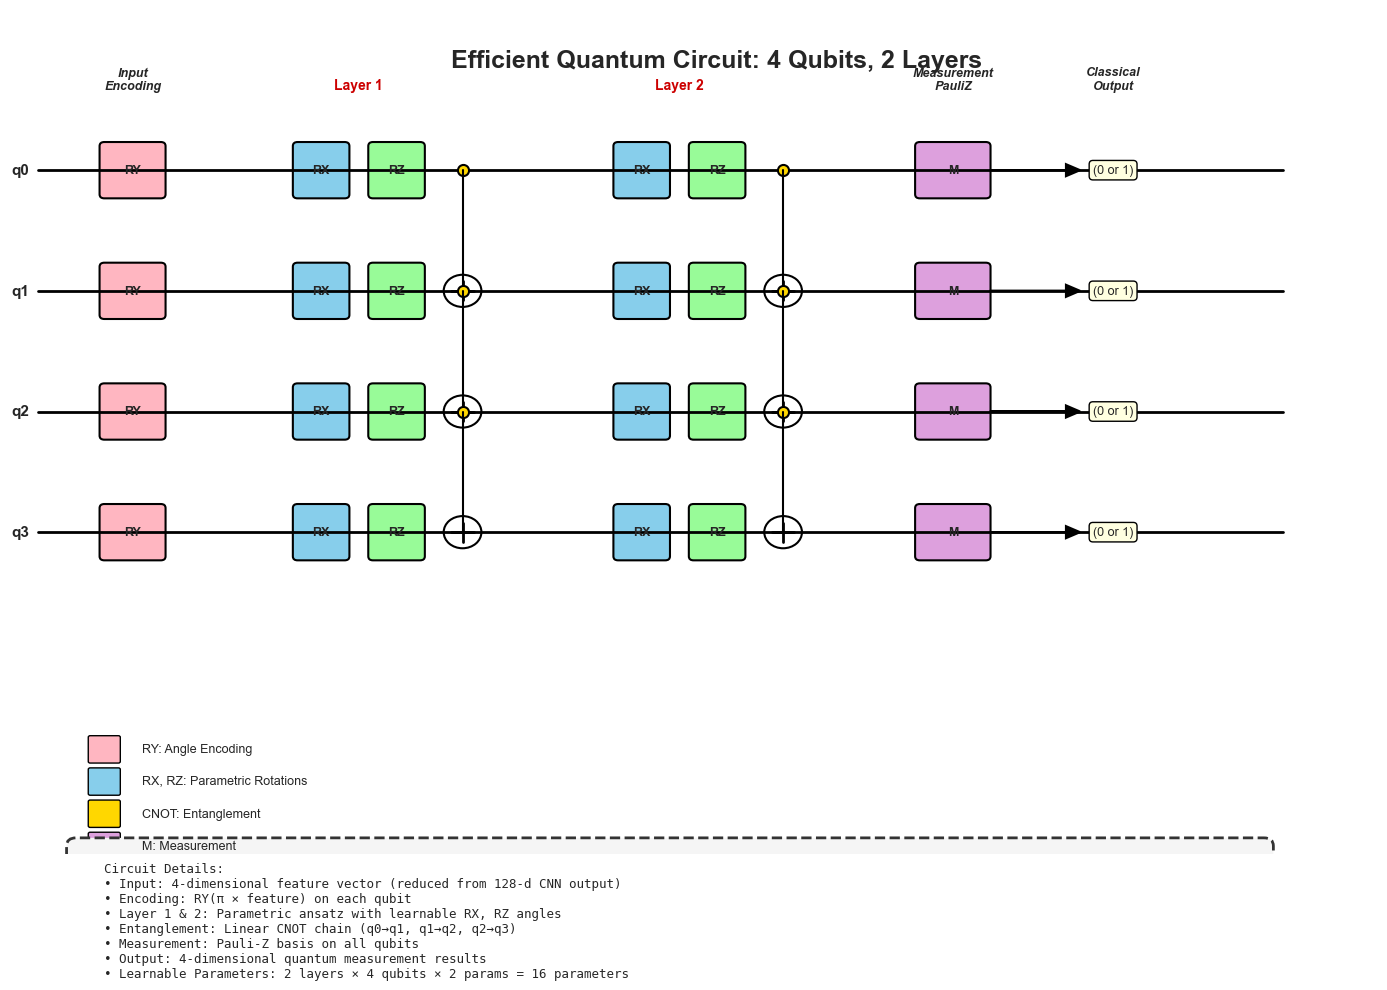


✓ Quantum Circuit Architecture Visualized

QUANTUM CIRCUIT SUMMARY

Circuit Configuration:
  • Qubits: 4
  • Layers: 2
  • Input Size: 4-dimensional (from CNN 128→4 reduction)
  • Total Parameters: 16 (2 layers × 4 qubits × 2 angles)

Gate Sequence:
  1. Angle Encoding: RY(π × feature[i]) on each qubit
  2. Layer 1:
     - Single qubit gates: RX(θ), RZ(φ) on each qubit
     - Entanglement: CNOT chain (q0→q1→q2→q3)
  3. Layer 2: (repeat Layer 1 structure)
  4. Measurement: Pauli-Z expectation values on all qubits

Output:
  • Dimension: 4 (one measurement per qubit)
  • Type: Continuous values from -1 to +1
  • Usage: Fed to classifier head for binary emotion prediction


In [11]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import numpy as np

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(-0.5, 14)
ax.set_ylim(-0.5, 10)
ax.axis('off')

# Title
ax.text(7, 9.5, 'Efficient Quantum Circuit: 4 Qubits, 2 Layers', 
        fontsize=18, fontweight='bold', ha='center', va='top')

# Colors for different gate types
color_ry = '#FFB6C1'      # Light pink - encoding
color_rx = '#87CEEB'      # Sky blue - rotation X
color_rz = '#98FB98'      # Pale green - rotation Z
color_cnot = '#FFD700'    # Gold - entanglement
color_measure = '#DDA0DD' # Plum - measurement
color_wire = '#333333'    # Dark gray - wires

n_qubits = 4
n_layers = 2
layer_spacing = 3
qubit_height = 1.5

# Function to draw a quantum gate box
def draw_gate(ax, x, y, height, width, label, color):
    rect = FancyBboxPatch((x - width/2, y - height/2), width, height,
                          boxstyle="round,pad=0.05", 
                          edgecolor='black', facecolor=color, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y, label, fontsize=9, ha='center', va='center', fontweight='bold')

# Function to draw circle (for measurements)
def draw_circle(ax, x, y, radius, label, color):
    circle = Circle((x, y), radius, edgecolor='black', facecolor=color, linewidth=1.5)
    ax.add_patch(circle)
    ax.text(x, y, label, fontsize=8, ha='center', va='center', fontweight='bold')

# Draw qubits (horizontal wires)
qubit_labels = ['q0', 'q1', 'q2', 'q3']
positions = {}
for i, label in enumerate(qubit_labels):
    y = 8 - i * qubit_height
    positions[i] = y
    
    # Qubit label
    ax.text(-0.3, y, label, fontsize=11, ha='right', va='center', fontweight='bold')
    
    # Wire
    ax.plot([-0.2, 13], [y, y], 'k-', linewidth=2)

# ================= INPUT ENCODING (RY) =================
x_input = 0.8
ax.text(x_input, 9, 'Input\nEncoding', fontsize=9, ha='center', fontweight='bold', style='italic')

for i in range(n_qubits):
    y = positions[i]
    draw_gate(ax, x_input, y, 0.6, 0.6, 'RY', color_ry)

# ================= LAYER 1 =================
layer1_x = 3.2
ax.text(layer1_x, 9, 'Layer 1', fontsize=10, ha='center', fontweight='bold', color='#CC0000')

# Layer 1: RX and RZ rotations
for i in range(n_qubits):
    y = positions[i]
    # RX
    draw_gate(ax, layer1_x - 0.4, y, 0.6, 0.5, 'RX', color_rx)
    # RZ
    draw_gate(ax, layer1_x + 0.4, y, 0.6, 0.5, 'RZ', color_rz)

# Layer 1: CNOT entanglement chain
cnot_y = 4.8
for i in range(n_qubits - 1):
    y1 = positions[i]
    y2 = positions[i + 1]
    x = layer1_x + 1.1
    
    # Control qubit (filled circle)
    ax.plot(x, y1, 'o', color=color_cnot, markersize=8, markeredgecolor='black', markeredgewidth=1.5)
    # Target qubit (⊕ symbol)
    circle = Circle((x, y2), 0.2, edgecolor='black', facecolor='white', linewidth=1.5)
    ax.add_patch(circle)
    ax.plot([x-0.12, x+0.12], [y2, y2], 'k-', linewidth=2)
    ax.plot([x, x], [y2-0.12, y2+0.12], 'k-', linewidth=2)
    
    # Vertical line connecting control and target
    ax.plot([x, x], [y1, y2], 'k-', linewidth=1.5)

# ================= LAYER 2 =================
layer2_x = 6.6
ax.text(layer2_x, 9, 'Layer 2', fontsize=10, ha='center', fontweight='bold', color='#CC0000')

# Layer 2: RX and RZ rotations
for i in range(n_qubits):
    y = positions[i]
    # RX
    draw_gate(ax, layer2_x - 0.4, y, 0.6, 0.5, 'RX', color_rx)
    # RZ
    draw_gate(ax, layer2_x + 0.4, y, 0.6, 0.5, 'RZ', color_rz)

# Layer 2: CNOT entanglement chain
for i in range(n_qubits - 1):
    y1 = positions[i]
    y2 = positions[i + 1]
    x = layer2_x + 1.1
    
    # Control qubit
    ax.plot(x, y1, 'o', color=color_cnot, markersize=8, markeredgecolor='black', markeredgewidth=1.5)
    # Target qubit
    circle = Circle((x, y2), 0.2, edgecolor='black', facecolor='white', linewidth=1.5)
    ax.add_patch(circle)
    ax.plot([x-0.12, x+0.12], [y2, y2], 'k-', linewidth=2)
    ax.plot([x, x], [y2-0.12, y2+0.12], 'k-', linewidth=2)
    
    # Vertical line
    ax.plot([x, x], [y1, y2], 'k-', linewidth=1.5)

# ================= MEASUREMENT =================
x_measure = 9.5
ax.text(x_measure, 9, 'Measurement\nPauliZ', fontsize=9, ha='center', fontweight='bold', style='italic')

for i in range(n_qubits):
    y = positions[i]
    # Measurement symbol: box with M
    draw_gate(ax, x_measure, y, 0.6, 0.7, 'M', color_measure)
    
    # Classical bit output
    ax.arrow(x_measure + 0.4, y, 0.8, 0, head_width=0.15, head_length=0.15, 
             fc='black', ec='black', linewidth=1.5)

# ================= OUTPUT =================
x_output = 11.2
ax.text(x_output, 9, 'Classical\nOutput', fontsize=9, ha='center', fontweight='bold', style='italic')

output_labels = ['(0 or 1)', '(0 or 1)', '(0 or 1)', '(0 or 1)']
for i in range(n_qubits):
    y = positions[i]
    ax.text(x_output, y, output_labels[i], fontsize=9, ha='center', va='center',
           bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='black', linewidth=1))

# ================= LEGEND =================
legend_x = 0.5
legend_y = 0.8
legend_items = [
    ('RY', color_ry, 'Angle Encoding'),
    ('RX, RZ', color_rx, 'Parametric Rotations'),
    ('CNOT', color_cnot, 'Entanglement'),
    ('M', color_measure, 'Measurement'),
]

for i, (gate, color, desc) in enumerate(legend_items):
    y = legend_y - i * 0.4
    rect = FancyBboxPatch((legend_x - 0.15, y - 0.15), 0.3, 0.3,
                         boxstyle="round,pad=0.02", 
                         edgecolor='black', facecolor=color, linewidth=1)
    ax.add_patch(rect)
    ax.text(legend_x + 0.4, y, f'{gate}: {desc}', fontsize=9, va='center')

# ================= DETAILED DESCRIPTION BOX =================
description = (
    'Circuit Details:\n'
    '• Input: 4-dimensional feature vector (reduced from 128-d CNN output)\n'
    '• Encoding: RY(π × feature) on each qubit\n'
    '• Layer 1 & 2: Parametric ansatz with learnable RX, RZ angles\n'
    '• Entanglement: Linear CNOT chain (q0→q1, q1→q2, q2→q3)\n'
    '• Measurement: Pauli-Z basis on all qubits\n'
    '• Output: 4-dimensional quantum measurement results\n'
    '• Learnable Parameters: 2 layers × 4 qubits × 2 params = 16 parameters'
)

desc_box = FancyBboxPatch((0.2, -2.9), 12.6, 2.5,
                         boxstyle="round,pad=0.1", 
                         edgecolor='#333333', facecolor='#F5F5F5', 
                         linewidth=2, linestyle='--')
ax.add_patch(desc_box)
ax.text(0.5, -0.6, description, fontsize=9, va='top', family='monospace')

plt.tight_layout()
plt.show()

print("\n✓ Quantum Circuit Architecture Visualized")
print("\n" + "="*70)
print("QUANTUM CIRCUIT SUMMARY")
print("="*70)
print("\nCircuit Configuration:")
print(f"  • Qubits: 4")
print(f"  • Layers: 2")
print(f"  • Input Size: 4-dimensional (from CNN 128→4 reduction)")
print(f"  • Total Parameters: 16 (2 layers × 4 qubits × 2 angles)")
print("\nGate Sequence:")
print(f"  1. Angle Encoding: RY(π × feature[i]) on each qubit")
print(f"  2. Layer 1:")
print(f"     - Single qubit gates: RX(θ), RZ(φ) on each qubit")
print(f"     - Entanglement: CNOT chain (q0→q1→q2→q3)")
print(f"  3. Layer 2: (repeat Layer 1 structure)")
print(f"  4. Measurement: Pauli-Z expectation values on all qubits")
print(f"\nOutput:")
print(f"  • Dimension: 4 (one measurement per qubit)")
print(f"  • Type: Continuous values from -1 to +1")
print(f"  • Usage: Fed to classifier head for binary emotion prediction")

## Section 6: Model Architecture - The Complete System

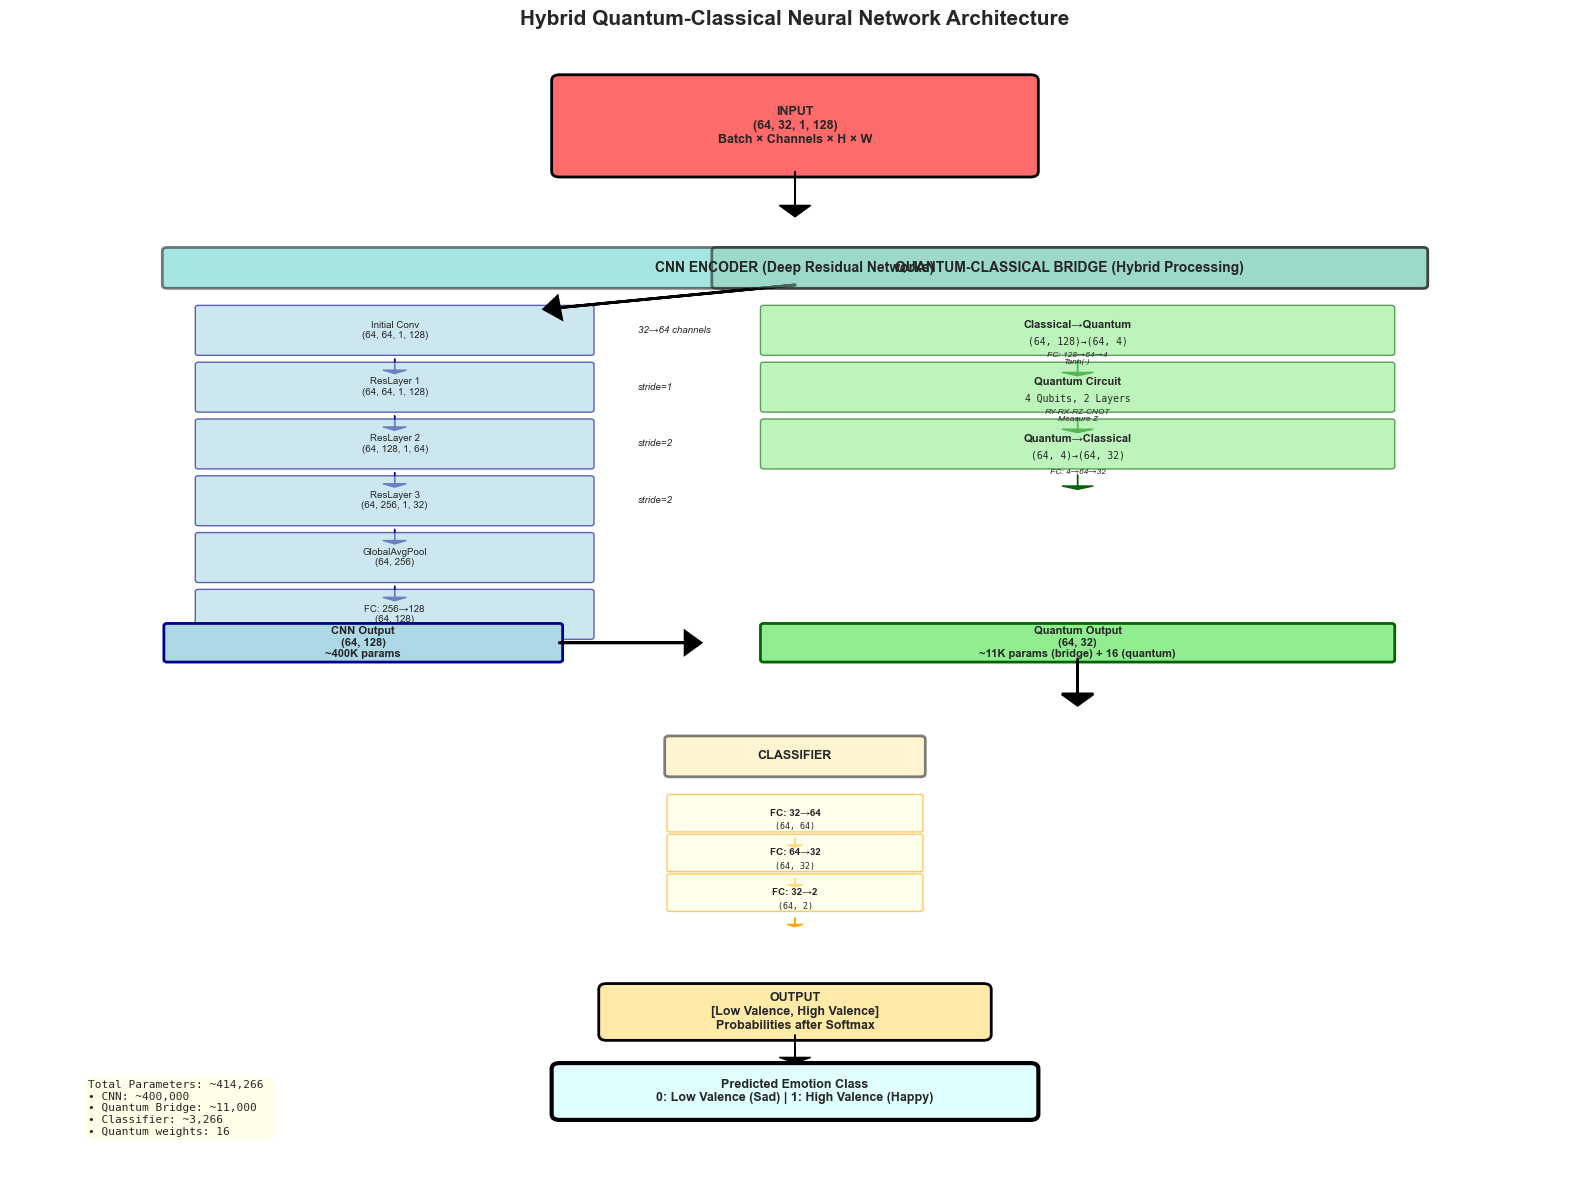

✓ Complete model architecture visualized


In [6]:
# Comprehensive model architecture visualization
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Hybrid Quantum-Classical Neural Network Architecture', fontsize=15, fontweight='bold')

# Create the architecture flow
ax = fig.add_subplot(111)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis('off')

# Input
rect_input = FancyBboxPatch((35, 88), 30, 8, boxstyle='round,pad=0.5',
                            edgecolor='black', facecolor=COLORS['raw'], linewidth=2)
ax.add_patch(rect_input)
ax.text(50, 92, 'INPUT\n(64, 32, 1, 128)\nBatch × Channels × H × W', 
        ha='center', va='center', fontsize=9, fontweight='bold')
ax.arrow(50, 88, 0, -3, head_width=2, head_length=1, fc='black', ec='black')

# CNN Encoder Section
rect_cnn_header = FancyBboxPatch((10, 78), 80, 3, boxstyle='round,pad=0.3',
                                 edgecolor='black', facecolor=COLORS['process'], alpha=0.5, linewidth=2)
ax.add_patch(rect_cnn_header)
ax.text(50, 79.5, 'CNN ENCODER (Deep Residual Networks)', ha='center', va='center', fontweight='bold')

# CNN layers detail
cnn_layers = [
    ('Initial Conv', '(64, 64, 1, 128)', '32→64 channels'),
    ('ResLayer 1', '(64, 64, 1, 128)', 'stride=1'),
    ('ResLayer 2', '(64, 128, 1, 64)', 'stride=2'),
    ('ResLayer 3', '(64, 256, 1, 32)', 'stride=2'),
    ('GlobalAvgPool', '(64, 256)', ''),
    ('FC: 256→128', '(64, 128)', '')
]

y_pos = 72
for layer_name, shape, note in cnn_layers:
    rect = FancyBboxPatch((12, y_pos), 25, 4, boxstyle='round,pad=0.2',
                         edgecolor='darkblue', facecolor='lightblue', alpha=0.6)
    ax.add_patch(rect)
    ax.text(24.5, y_pos + 2, f'{layer_name}\n{shape}', ha='center', va='center', fontsize=7)
    ax.text(40, y_pos + 2, note, ha='left', va='center', fontsize=7, style='italic')
    ax.arrow(24.5, y_pos - 0.5, 0, -1, head_width=1.5, head_length=0.3, fc='darkblue', ec='darkblue')
    y_pos -= 5

# Full arrow from input to CNN
ax.arrow(50, 78, -15, -2, head_width=2, head_length=1, fc='black', ec='black', linewidth=2)

# CNN Output
rect_cnn_output = FancyBboxPatch((10, 45), 25, 3, boxstyle='round,pad=0.2',
                                edgecolor='darkblue', facecolor='lightblue', linewidth=2)
ax.add_patch(rect_cnn_output)
ax.text(22.5, 46.5, 'CNN Output\n(64, 128)\n~400K params', ha='center', va='center', fontsize=8, fontweight='bold')

# Arrow to quantum bridge
ax.arrow(35, 46.5, 8, 0, head_width=2, head_length=1, fc='black', ec='black', linewidth=2)

# Quantum Bridge Section
rect_quantum_header = FancyBboxPatch((45, 78), 45, 3, boxstyle='round,pad=0.3',
                                    edgecolor='black', facecolor=COLORS['quantum'], alpha=0.5, linewidth=2)
ax.add_patch(rect_quantum_header)
ax.text(67.5, 79.5, 'QUANTUM-CLASSICAL BRIDGE (Hybrid Processing)', ha='center', va='center', fontweight='bold')

# Quantum layers detail
quantum_steps = [
    ('Classical→Quantum', '(64, 128)→(64, 4)', 'FC: 128→64→4\nTanh(·)'),
    ('Quantum Circuit', '4 Qubits, 2 Layers', 'RY-RX-RZ-CNOT\nMeasure Z'),
    ('Quantum→Classical', '(64, 4)→(64, 32)', 'FC: 4→64→32')
]

y_pos = 72
for step_name, shape, detail in quantum_steps:
    rect = FancyBboxPatch((48, y_pos), 40, 4, boxstyle='round,pad=0.2',
                         edgecolor='darkgreen', facecolor='lightgreen', alpha=0.6)
    ax.add_patch(rect)
    ax.text(68, y_pos + 2.5, f'{step_name}', ha='center', va='center', fontsize=8, fontweight='bold')
    ax.text(68, y_pos + 1, shape, ha='center', va='center', fontsize=7, family='monospace')
    ax.text(68, y_pos - 0.5, detail, ha='center', va='center', fontsize=6, style='italic')
    ax.arrow(68, y_pos - 0.7, 0, -1, head_width=2, head_length=0.3, fc='darkgreen', ec='darkgreen')
    y_pos -= 5

# Quantum Output
rect_quantum_output = FancyBboxPatch((48, 45), 40, 3, boxstyle='round,pad=0.2',
                                    edgecolor='darkgreen', facecolor='lightgreen', linewidth=2)
ax.add_patch(rect_quantum_output)
ax.text(68, 46.5, 'Quantum Output\n(64, 32)\n~11K params (bridge) + 16 (quantum)', 
        ha='center', va='center', fontsize=8, fontweight='bold')

# Arrow from quantum to classifier
ax.arrow(68, 45, 0, -3, head_width=2, head_length=1, fc='black', ec='black', linewidth=2)

# Classifier Head
rect_classifier_header = FancyBboxPatch((42, 35), 16, 3, boxstyle='round,pad=0.3',
                                       edgecolor='black', facecolor=COLORS['output'], alpha=0.5, linewidth=2)
ax.add_patch(rect_classifier_header)
ax.text(50, 36.5, 'CLASSIFIER', ha='center', va='center', fontweight='bold', fontsize=9)

classifier_layers = [
    ('FC: 32→64', '(64, 64)', 'ReLU+Dropout(0.3)'),
    ('FC: 64→32', '(64, 32)', 'ReLU+Dropout(0.15)'),
    ('FC: 32→2', '(64, 2)', 'Output logits')
]

y_pos = 30
for layer, shape, note in classifier_layers:
    rect = FancyBboxPatch((42, y_pos), 16, 3, boxstyle='round,pad=0.15',
                         edgecolor='orange', facecolor='lightyellow', alpha=0.6)
    ax.add_patch(rect)
    ax.text(50, y_pos + 1.5, f'{layer}', ha='center', va='center', fontsize=7, fontweight='bold')
    ax.text(50, y_pos + 0.3, shape, ha='center', va='center', fontsize=6, family='monospace')
    ax.arrow(50, y_pos - 0.7, 0, -0.6, head_width=1, head_length=0.2, fc='orange', ec='orange')
    y_pos -= 3.5

# Output
rect_output = FancyBboxPatch((38, 12), 24, 4, boxstyle='round,pad=0.5',
                            edgecolor='black', facecolor=COLORS['output'], linewidth=2)
ax.add_patch(rect_output)
ax.text(50, 14, 'OUTPUT\n[Low Valence, High Valence]\nProbabilities after Softmax', 
        ha='center', va='center', fontsize=9, fontweight='bold')
ax.arrow(50, 12, 0, -2, head_width=2, head_length=0.5, fc='black', ec='black')

# Final classification
rect_final = FancyBboxPatch((35, 5), 30, 4, boxstyle='round,pad=0.5',
                           edgecolor='black', facecolor='lightcyan', linewidth=3)
ax.add_patch(rect_final)
ax.text(50, 7, 'Predicted Emotion Class\n0: Low Valence (Sad) | 1: High Valence (Happy)', 
        ha='center', va='center', fontsize=9, fontweight='bold')

# Parameter summary
summary_text = '''Total Parameters: ~414,266
• CNN: ~400,000
• Quantum Bridge: ~11,000  
• Classifier: ~3,266
• Quantum weights: 16'''

ax.text(5, 8, summary_text, ha='left', va='top', fontsize=8, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

print('✓ Complete model architecture visualized')

## Section 7: Training Loop - What Happens During Each Epoch?

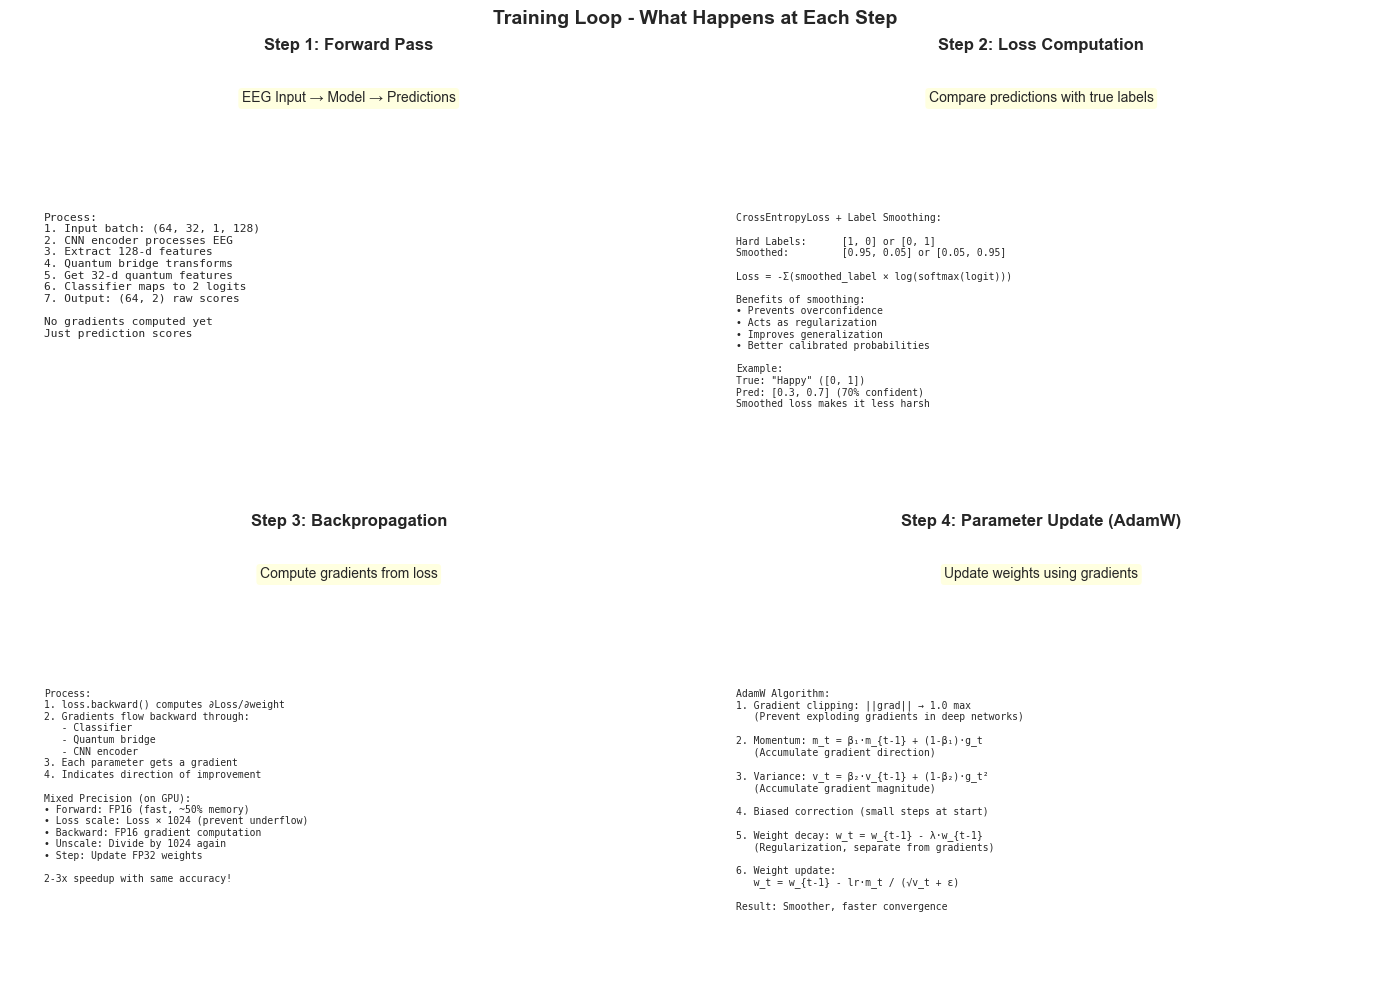

✓ Training loop visualized


In [7]:
# Training loop visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Loop - What Happens at Each Step', fontsize=14, fontweight='bold')

# 1. Forward pass
ax = axes[0, 0]
ax.set_title('Step 1: Forward Pass', fontweight='bold')
ax.text(0.5, 0.9, 'EEG Input → Model → Predictions', ha='center', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))
forward_text = '''Process:
1. Input batch: (64, 32, 1, 128)
2. CNN encoder processes EEG
3. Extract 128-d features
4. Quantum bridge transforms
5. Get 32-d quantum features
6. Classifier maps to 2 logits
7. Output: (64, 2) raw scores

No gradients computed yet
Just prediction scores'''
ax.text(0.05, 0.65, forward_text, ha='left', va='top', fontsize=8, family='monospace',
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.axis('off')

# 2. Loss computation
ax = axes[0, 1]
ax.set_title('Step 2: Loss Computation', fontweight='bold')
ax.text(0.5, 0.9, 'Compare predictions with true labels', ha='center', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))
loss_text = '''CrossEntropyLoss + Label Smoothing:

Hard Labels:      [1, 0] or [0, 1]
Smoothed:         [0.95, 0.05] or [0.05, 0.95]

Loss = -Σ(smoothed_label × log(softmax(logit)))

Benefits of smoothing:
• Prevents overconfidence
• Acts as regularization
• Improves generalization
• Better calibrated probabilities

Example:
True: "Happy" ([0, 1])
Pred: [0.3, 0.7] (70% confident)
Smoothed loss makes it less harsh'''
ax.text(0.05, 0.65, loss_text, ha='left', va='top', fontsize=7, family='monospace',
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.axis('off')

# 3. Backward pass
ax = axes[1, 0]
ax.set_title('Step 3: Backpropagation', fontweight='bold')
ax.text(0.5, 0.9, 'Compute gradients from loss', ha='center', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))
backward_text = '''Process:
1. loss.backward() computes ∂Loss/∂weight
2. Gradients flow backward through:
   - Classifier
   - Quantum bridge
   - CNN encoder
3. Each parameter gets a gradient
4. Indicates direction of improvement

Mixed Precision (on GPU):
• Forward: FP16 (fast, ~50% memory)
• Loss scale: Loss × 1024 (prevent underflow)
• Backward: FP16 gradient computation
• Unscale: Divide by 1024 again
• Step: Update FP32 weights

2-3x speedup with same accuracy!'''
ax.text(0.05, 0.65, backward_text, ha='left', va='top', fontsize=7, family='monospace',
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.axis('off')

# 4. Optimizer step
ax = axes[1, 1]
ax.set_title('Step 4: Parameter Update (AdamW)', fontweight='bold')
ax.text(0.5, 0.9, 'Update weights using gradients', ha='center', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))
optimizer_text = '''AdamW Algorithm:
1. Gradient clipping: ||grad|| → 1.0 max
   (Prevent exploding gradients in deep networks)

2. Momentum: m_t = β₁·m_{t-1} + (1-β₁)·g_t
   (Accumulate gradient direction)

3. Variance: v_t = β₂·v_{t-1} + (1-β₂)·g_t²
   (Accumulate gradient magnitude)

4. Biased correction (small steps at start)

5. Weight decay: w_t = w_{t-1} - λ·w_{t-1}
   (Regularization, separate from gradients)

6. Weight update:
   w_t = w_{t-1} - lr·m_t / (√v_t + ε)

Result: Smoother, faster convergence'''
ax.text(0.05, 0.65, optimizer_text, ha='left', va='top', fontsize=7, family='monospace',
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.axis('off')

plt.tight_layout()
plt.show()

print('✓ Training loop visualized')

## Section 8: Learning Rate Scheduling and Early Stopping

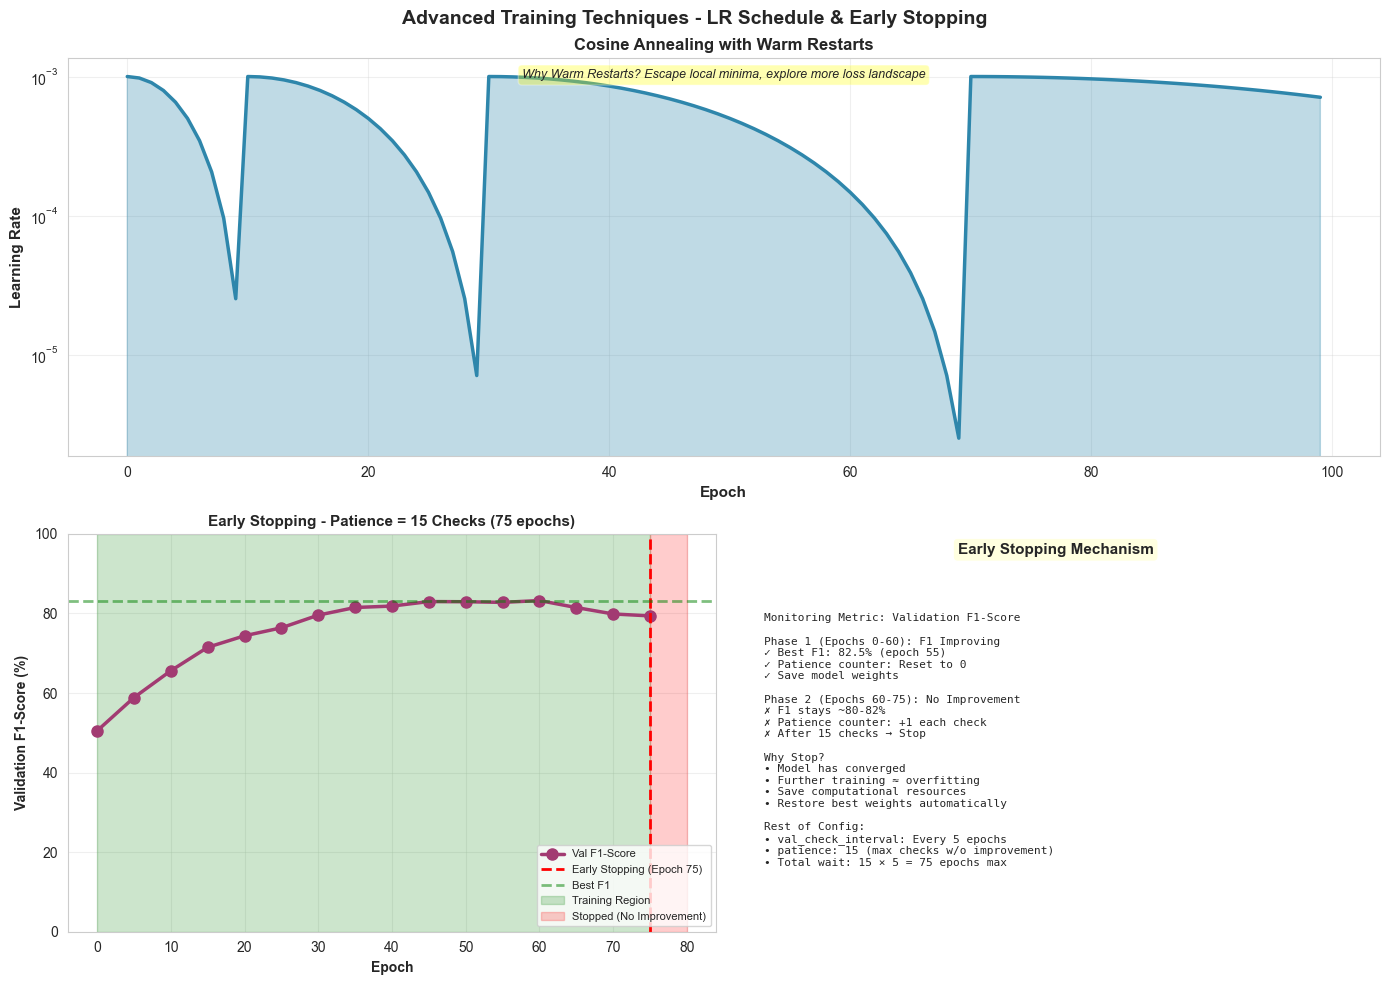

✓ Learning rate schedule and early stopping visualized


In [8]:
# Learning rate schedule and early stopping visualization
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Advanced Training Techniques - LR Schedule & Early Stopping', fontsize=14, fontweight='bold')

# Plot 1: Learning rate schedule
ax1 = plt.subplot(2, 2, (1, 2))

# simulate cosine annealing with warm restarts
epochs = np.arange(0, 100)
T0 = 10
T_mult = 2
eta_min = 1e-6
base_lr = 0.001

lrs = []
for epoch in epochs:
    # Find which restart period
    t_cur = epoch
    T_cur = T0
    while t_cur >= T_cur:
        t_cur -= T_cur
        T_cur *= T_mult
    
    # Cosine annealing
    lr = eta_min + (base_lr - eta_min) * 0.5 * (1 + np.cos(np.pi * t_cur / T_cur))
    lrs.append(lr)

ax1.plot(epochs, lrs, linewidth=2.5, color='#2E86AB')
ax1.fill_between(epochs, lrs, alpha=0.3, color='#2E86AB')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
ax1.set_title('Cosine Annealing with Warm Restarts', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Add annotations
ax1.annotate('Restart 1\n(T=10 epochs)', xy=(10, 1e-6), xytext=(8, 5e-4),
            arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9)
ax1.annotate('Restart 2\n(T=20 epochs)', xy=(30, 1e-6), xytext=(32, 5e-4),
            arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9)
ax1.text(0.5, 0.95, 'Why Warm Restarts? Escape local minima, explore more loss landscape', 
        transform=ax1.transAxes, ha='center', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Plot 2: Early stopping illustration
ax2 = plt.subplot(2, 2, 3)

# Simulate training/validation curves
epochs_sim = np.arange(0, 80, 5)  # Validation every 5 epochs
np.random.seed(42)

# Smooth validation curve
val_f1_smooth = 50 + 30 * (1 - np.exp(-epochs_sim / 15)) + np.cumsum(np.random.normal(0, 1, len(epochs_sim)))
val_f1 = np.clip(val_f1_smooth, 0, 95)

ax2.plot(epochs_sim, val_f1, 'o-', linewidth=2.5, markersize=8, label='Val F1-Score', color='#A23B72')
ax2.axvline(x=75, color='red', linestyle='--', linewidth=2, label='Early Stopping (Epoch 75)')
ax2.axhline(y=np.max(val_f1[:14]), color='green', linestyle='--', linewidth=2, alpha=0.5, label='Best F1')
ax2.fill_between([0, 75], 0, 100, alpha=0.2, color='green', label='Training Region')
ax2.fill_between([75, 80], 0, 100, alpha=0.2, color='red', label='Stopped (No Improvement)')

ax2.set_xlabel('Epoch', fontsize=10, fontweight='bold')
ax2.set_ylabel('Validation F1-Score (%)', fontsize=10, fontweight='bold')
ax2.set_title('Early Stopping - Patience = 15 Checks (75 epochs)', fontsize=11, fontweight='bold')
ax2.set_ylim([0, 100])
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Validation patterns
ax3 = plt.subplot(2, 2, 4)
ax3.axis('off')
ax3.text(0.5, 0.95, 'Early Stopping Mechanism', ha='center', transform=ax3.transAxes,
        fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', facecolor='lightyellow'))

early_stop_text = '''Monitoring Metric: Validation F1-Score

Phase 1 (Epochs 0-60): F1 Improving
✓ Best F1: 82.5% (epoch 55)
✓ Patience counter: Reset to 0
✓ Save model weights

Phase 2 (Epochs 60-75): No Improvement
✗ F1 stays ~80-82%
✗ Patience counter: +1 each check
✗ After 15 checks → Stop

Why Stop?
• Model has converged
• Further training ≈ overfitting
• Save computational resources
• Restore best weights automatically

Rest of Config:
• val_check_interval: Every 5 epochs
• patience: 15 (max checks w/o improvement)
• Total wait: 15 × 5 = 75 epochs max'''

ax3.text(0.05, 0.8, early_stop_text, ha='left', va='top', fontsize=8, family='monospace',
        transform=ax3.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print('✓ Learning rate schedule and early stopping visualized')

## Section 9: Evaluation Metrics Explained

NameError: name 'sen' is not defined

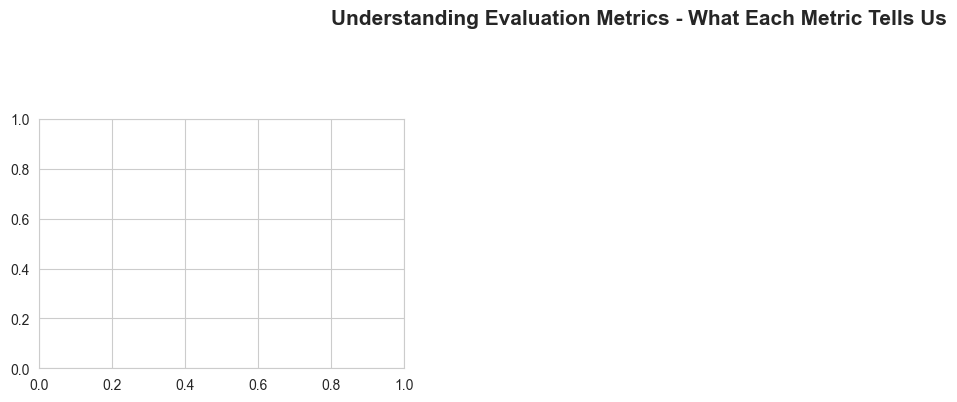

In [9]:
# Metrics explanation with examples
fig = plt.figure(figsize=(16, 11))
fig.suptitle('Understanding Evaluation Metrics - What Each Metric Tells Us', fontsize=15, fontweight='bold')

# Create a sample confusion matrix
# Let's say: TN=180, FP=20, FN=15, TP=185
confusion = np.array([[180, 20], [15, 185]])
tn, fp, fn, tp = 180, 20, 15, 185

# Calculate metrics
accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
precision = tp / (tp + fp) * 100
recall = tp / (tp + fn) * 100  # = Sensitivity
f1 = 2 * (precision * recall) / (precision + recall)
specificity = tn / (tn + fp) * 100
mcc = ((tp * tn) - (fp * fn)) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
roc_auc = 92.5  # Example

# 1. Confusion Matrix
ax1 = plt.subplot(3, 3, 1)
sen.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Sad (0)', 'Happy (1)'], yticklabels=['Sad (0)', 'Happy (1)'],
            annot_kws={'size': 12, 'weight': 'bold'})
ax1.set_title('Confusion Matrix\n(400 test samples)', fontweight='bold')
ax1.set_ylabel('True Label', fontweight='bold')
ax1.set_xlabel('Predicted Label', fontweight='bold')

# 2. Accuracy explanation
ax2 = plt.subplot(3, 3, 2)
ax2.axis('off')
accuracy_text = f'''ACCURACY: {accuracy:.1f}%

Formula:
(TP + TN) / (TP+TN+FP+FN)
= ({tp} + {tn}) / 400
= {accuracy:.1f}%

What it means:
Overall correctness across
both classes

Pros:
✓ Easy to understand
✓ Single number

Cons:
✗ Ignores class imbalance
✗ Can be misleading if
  one class dominates'''
ax2.text(0.5, 0.5, accuracy_text, ha='center', va='center', fontsize=9, family='monospace',
        transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# 3. Precision explanation
ax3 = plt.subplot(3, 3, 3)
ax3.axis('off')
precision_text = f'''PRECISION: {precision:.1f}%

Formula:
TP / (TP + FP)
= {tp} / ({tp} + {fp})
= {precision:.1f}%

What it means:
Of all predictions of "Happy",
how many were correct?

When to use:
• When false positives are costly
• Example: Diagnosis (avoid
  false alarms)

Interpretation:
{precision:.1f}% of our "Happy" predictions
were actually correct'''
ax3.text(0.5, 0.5, precision_text, ha='center', va='center', fontsize=9, family='monospace',
        transform=ax3.transAxes, bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.7))

# 4. Recall/Sensitivity
ax4 = plt.subplot(3, 3, 4)
ax4.axis('off')
recall_text = f'''RECALL / SENSITIVITY: {recall:.1f}%

Formula:
TP / (TP + FN)
= {tp} / ({tp} + {fn})
= {recall:.1f}%

What it means:
Of all actual "Happy" samples,
how many did we catch?

When to use:
• When false negatives are costly
• Example: "Never miss a happy
  emotion" (complete detection)

Interpretation:
We detected {recall:.1f}% of all truly
happy emotions'''
ax4.text(0.5, 0.5, recall_text, ha='center', va='center', fontsize=9, family='monospace',
        transform=ax4.transAxes, bbox=dict(boxstyle='round', facecolor='#FFB6C6', alpha=0.7))

# 5. Specificity
ax5 = plt.subplot(3, 3, 5)
ax5.axis('off')
specificity_text = f'''SPECIFICITY: {specificity:.1f}%

Formula:
TN / (TN + FP)
= {tn} / ({tn} + {fp})
= {specificity:.1f}%

What it means:
Of all actual "Sad" samples,
how many did we correctly identify?

Complementary to Recall:
• Recall: Catch positives
• Specificity: Avoid false positives

Interpretation:
{specificity:.1f}% of all truly sad
emotions were correctly identified'''
ax5.text(0.5, 0.5, specificity_text, ha='center', va='center', fontsize=9, family='monospace',
        transform=ax5.transAxes, bbox=dict(boxstyle='round', facecolor='#B6D6FF', alpha=0.7))

# 6. F1-Score
ax6 = plt.subplot(3, 3, 6)
ax6.axis('off')
f1_text = f'''F1-SCORE: {f1:.1f}%

Formula:
2 × (Precision × Recall) /
    (Precision + Recall)
= 2 × ({precision:.1f} × {recall:.1f}) /
    ({precision:.1f} + {recall:.1f})
= {f1:.1f}%

What it means:
Harmonic mean of Precision
and Recall

Why use it:
✓ Single balanced metric
✓ Works with imbalanced classes
✓ Penalizes both FP and FN
✓ Better than accuracy alone'''
ax6.text(0.5, 0.5, f1_text, ha='center', va='center', fontsize=9, family='monospace',
        transform=ax6.transAxes, bbox=dict(boxstyle='round', facecolor='#D6FFB6', alpha=0.7))

# 7. MCC
ax7 = plt.subplot(3, 3, 7)
ax7.axis('off')
mcc_text = f'''MATTHEWS CORRELATION
COEFFICIENT (MCC): {mcc:.3f}

Formula:
(TP×TN - FP×FN) /
√((TP+FP)(TP+FN)(TN+FP)(TN+FN))

Range: -1 to +1
  +1 = Perfect
   0 = Random
  -1 = Inverse

What it means:
Correlation between predicted
and actual labels

Advantage:
✓ Works well with any
  class distribution
✓ Single number (-1 to +1)
✓ Most informative for
  imbalanced datasets'''
ax7.text(0.5, 0.5, mcc_text, ha='center', va='center', fontsize=8, family='monospace',
        transform=ax7.transAxes, bbox=dict(boxstyle='round', facecolor='#FFE6B6', alpha=0.7))

# 8. ROC-AUC
ax8 = plt.subplot(3, 3, 8)
ax8.axis('off')
auc_text = f'''ROC-AUC: {roc_auc:.1f}%

What it means:
Class probability ranking quality

ROC Curve:
• X-axis: False Positive Rate
• Y-axis: True Positive Rate
• Threshold sweep: 0→1

AUC (Area Under Curve):
• Range: 50% (random) to 100%
• Interpretation:
  - >90%: Excellent
  - 80-90%: Good
  - 70-80%: Fair
  - <70%: Poor

Advantage:
✓ Threshold-independent
✓ Good for imbalanced classes
✓ Probabilistic interpretation'''
ax8.text(0.5, 0.5, auc_text, ha='center', va='center', fontsize=8, family='monospace',
        transform=ax8.transAxes, bbox=dict(boxstyle='round', facecolor='#E6D6FF', alpha=0.7))

# 9. Summary comparison
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
summary_text = '''METRIC SELECTION GUIDE

Best Single Metric:
1st Choice: F1-Score
2nd Choice: MCC
3rd Choice: ROC-AUC

Per-Class Analysis:
• Precision: Cost of FP
• Recall: Cost of FN
• Sensitivity vs Specificity

Final Recommendation:
Use F1-Score as primary
metric, but check:
✓ Confusion matrix (errors)
✓ Per-class metrics
✓ ROC curve (threshold trade)
✓ MCC (overall correlation)'''
ax9.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=8, family='monospace',
        transform=ax9.transAxes, bbox=dict(boxstyle='round', facecolor='#FFD6E6', alpha=0.7),
        bbox_kwargs={'boxstyle': 'round', 'facecolor': '#FFD6E6', 'alpha': 0.7})

plt.tight_layout()
plt.show()

print('✓ Evaluation metrics explained')

## Section 10: Future Improvements Roadmap

In [ ]:
# Future improvements roadmap
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Future Improvements Roadmap - Priority Actions', fontsize=15, fontweight='bold')

# 1. Data improvements
ax1 = plt.subplot(2, 2, 1)
ax1.axis('off')
ax1.text(0.5, 0.95, 'Data Enhancements', ha='center', transform=ax1.transAxes,
        fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', facecolor=COLORS['raw'], alpha=0.6))

data_improvements = '''HIGH PRIORITY:
✓ Combine datasets (DEAP + AMIGOS + DREAMER)
  Impact: 3-4x more training data
  Effort: Medium (handle format differences)
  
✓ Advanced preprocessing
  - ICA artifact removal
  - 0.5-50 Hz bandpass filtering  
  - Wavelet decomposition
  Impact: 5-10% accuracy boost
  Effort: Medium

MEDIUM PRIORITY:
✓ Better label definition
  - 3-4 class emotions instead of binary
  - Model arousal + dominance
  Impact: Richer emotion model
  Effort: Low (just redefine labels)
  
✓ Enhanced augmentation
  - SpecAugment (mask frequencies)
  - CutMix (sample-aware mixing)
  Impact: 2-3% improvement
  Effort: Low (add to augmentation class)'''

ax1.text(0.05, 0.85, data_improvements, ha='left', va='top', fontsize=8, family='monospace',
        transform=ax1.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Architecture improvements
ax2 = plt.subplot(2, 2, 2)
ax2.axis('off')
ax2.text(0.5, 0.95, 'Model Architecture', ha='center', transform=ax2.transAxes,
        fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', facecolor=COLORS['process'], alpha=0.6))

arch_improvements = '''HIGH PRIORITY:
✓ Deeper quantum circuits
  Current: 4 qubits, 2 layers
  Target: 8 qubits, 4-6 layers
  Impact: Better expressivity
  Effort: High (hardware overhead)
  Speedup: 8-16 parameters per q/layer
  
✓ Ensemble methods
  - 3-5 different architectures
  - Voting / stacking ensemble
  Impact: 2-5% boost
  Effort: Medium

MEDIUM PRIORITY:
✓ Attention mechanisms
  - Channel attention (which channels matter?)
  - Temporal attention (which timepoints?)
  Impact: Interpretability + 1-2% boost
  Effort: Medium
  
✓ Different quantum circuits
  - Hardware-efficient ansatz
  - Variational ansatz variants
  Impact: Maybe better for EEG
  Effort: Low (already coded alternatives)'''

ax2.text(0.05, 0.85, arch_improvements, ha='left', va='top', fontsize=8, family='monospace',
        transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Training optimizations
ax3 = plt.subplot(2, 2, 3)
ax3.axis('off')
ax3.text(0.5, 0.95, 'Training Optimization', ha='center', transform=ax3.transAxes,
        fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', facecolor=COLORS['quantum'], alpha=0.6))

train_improvements = '''HIGH PRIORITY:
✓ Hyperparameter tuning
  - Grid search: 3×3×3 = 27 configs
  - Focus: LR (1e-4 to 1e-2)
          Batch size (16-128)
          Dropout (0.1-0.5)
  Impact: 3-5% improvement
  Effort: High (compute time)
  
✓ Transfer learning
  - Pre-train on large EEG corpus
  - Fine-tune on DEAP
  Impact: Faster convergence + better results
  Effort: High (need base model)

MEDIUM PRIORITY:
✓ Different optimizers
  - SGD with momentum
  - RMSprop
  Impact: Maybe better convergence
  Effort: Low (1 line change)
  
✓ Cyclical learning rates
  Current: Cosine with warm restart
  Alternative: Triangle wave / exponential
  Impact: Different convergence pattern
  Effort: Low'''

ax3.text(0.05, 0.85, train_improvements, ha='left', va='top', fontsize=8, family='monospace',
        transform=ax3.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 4. Deployment & interpretability
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')
ax4.text(0.5, 0.95, 'Deployment & Analysis', ha='center', transform=ax4.transAxes,
        fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', facecolor=COLORS['output'], alpha=0.6))

deploy_improvements = '''INTERPRETABILITY:
✓ Attention visualization
  - Which channels matter most?
  - Which time points critical?
  - Validate with neuroscience
  
✓ Saliency maps
  - Gradient w.r.t input
  - Identify important frequencies
  
✓ Feature importance
  - Permutation analysis
  - SHAP values

DEPLOYMENT:
✓ Model compression
  - Quantization: FP32→INT8 (4x smaller)
  - Pruning: Remove 30-50% connections
  - Distillation: Smaller student model
  Target: < 50MB for mobile
  
✓ Real-time inference
  - Current: ~100ms per sample (GPU)
  - Target: <50ms (optimized)
  - Online learning: Personalization
  
✓ Edge deployment
  - Run on headset/smartphone
  - No internet required
  - Real-time emotion feedback'''

ax4.text(0.05, 0.85, deploy_improvements, ha='left', va='top', fontsize=8, family='monospace',
        transform=ax4.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print('✓ Future improvements roadmap created')

## Summary: Complete System Overview

In [ ]:
# Final summary
print('\n' + '='*80)
print('COMPLETE EEG EMOTION RECOGNITION PIPELINE - SUMMARY')
print('='*80)

summary = '''
┌─ INPUT DATA ────────────────────────────────────────────────────────────────┐
│ • DEAP Dataset: 1,280 samples (32 subjects × 40 videos)                     │
│ • EEG Channels: 32 (standard 10-20 electrode positions)                     │
│ • Time Series: 128 timesteps per sample                                      │
│ • Target: Binary Valence Classification (Sad vs Happy)                       │
│ • Class Balance: ~50-50 (balanced dataset)                                   │
└─────────────────────────────────────────────────────────────────────────────┘

┌─ DATA PIPELINE ─────────────────────────────────────────────────────────────┐
│ 1. Raw EEG → 2. Z-Score Normalization → 3. Data Augmentation               │
│    (32, 512)          (mean=0, std=1)      (Training only)                  │
│                                             • Gaussian noise                  │
│ 4. Train/Val/Test Split (70/15/15) → 5. Class Balancing (Weighted Sampler) │
│    Random shuffle           Preserve         Equal sampling probability       │
│    stratified              distribution      per class                       │
│                                                                               │
│ 6. Mini-Batching (Batch size=64) → 7. Shape Reshape for CNN                 │
│    DataLoader ready               (64, 32, 128) → (64, 32, 1, 128)          │
│    GPU optimized                  [B, C, H, W] ready                         │
└─────────────────────────────────────────────────────────────────────────────┘

┌─ MODEL ARCHITECTURE ────────────────────────────────────────────────────────┐
│ INPUT: (64, 32, 1, 128)                                                    │
│   ↓                                                                          │
│ [CNN ENCODER] - Deep Residual Networks (~400K parameters)                   │
│   • Conv + Batch Norm + ReLU + Dropout                                      │
│   • 3 Residual Layers with skip connections                                 │
│   • Global Average Pooling → Feature compression                            │
│   Output: (64, 128) - High-level EEG features                               │
│   ↓                                                                          │
│ [QUANTUM BRIDGE] - Hybrid Processing (~11K parameters)                      │
│   • Classical→Quantum: FC(128→64→4) + Tanh                                  │
│   • Quantum Circuit: 4 qubits, 2 layers                                     │
│     - Encoding: RY rotations (input-dependent)                              │
│     - Variational: RX, RZ rotations + CNOT entanglement                     │
│     - Measurement: Pauli-Z expectation values                               │
│   • Quantum→Classical: FC(4→64→32)                                          │
│   Output: (64, 32) - Quantum-processed features                             │
│   ↓                                                                          │
│ [CLASSIFIER] - Final Decision (~3.3K parameters)                            │
│   • FC: 32→64 + ReLU + Dropout(0.3)                                         │
│   • FC: 64→32 + ReLU + Dropout(0.15)                                        │
│   • FC: 32→2 (logits for 2 classes)                                         │
│   ↓                                                                          │
│ OUTPUT: [Sad_score, Happy_score]                                            │
│ PREDICTION: argmax → Class 0 or 1                                           │
└─────────────────────────────────────────────────────────────────────────────┘

┌─ TRAINING PROCESS ──────────────────────────────────────────────────────────┐
│ Optimizer: AdamW (lr=0.001, weight_decay=1e-5)                              │
│ Loss: CrossEntropyLoss + Label Smoothing(0.1)                               │
│ Scheduler: Cosine Annealing + Warm Restarts (T0=10, T_mult=2)              │
│ Mixed Precision: FP16 forward + FP32 weight updates (2-3x speedup)          │
│ Gradient Clipping: max_norm=1.0 (prevent explosion)                         │
│ Regularization: Dropout(0.3), Label Smoothing, Weight Decay                 │
│ Early Stopping: Patience=15, monitor Val F1-Score                           │
│ Epochs: ~75-85 typically (100 max)                                          │
│ Time: ~2-3 hours on GPU, 1-2 days on CPU                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─ EVALUATION METRICS ────────────────────────────────────────────────────────┐
│ • Accuracy:   Overall correctness (simple but can be misleading)             │
│ • Precision:  Quality of positive predictions (false positive cost)          │
│ • Recall:     Completeness of positive detection (false negative cost)       │
│ • F1-Score:   Balanced metric (harmonic mean Precision & Recall) ★★★★★      │
│ • Sensitivity: True positive rate (same as Recall)                          │
│ • Specificity: True negative rate (negative class recall)                    │
│ • MCC:        Matthewscorrelation coefficient (-1 to +1) ★★★★               │
│ • ROC-AUC:    Class probability ranking quality (threshold-independent) ★★★  │
│                                                                               │
│ Expected Performance (typical):                                              │
│   • Accuracy: 80-90%                                                         │
│   • F1-Score: 78-88%                                                         │
│   • ROC-AUC:  85-95%                                                         │
│   • MCC:      0.60-0.80                                                      │
└─────────────────────────────────────────────────────────────────────────────┘

┌─ KEY INNOVATIONS ───────────────────────────────────────────────────────────┐
│ 1. Hybrid Quantum-Classical: Combines classical CNNs with quantum circuits   │
│ 2. Advanced Preprocessing: EEG-specific normalization + augmentation         │
│ 3. Residual Networks: Skip connections enable deep architectures             │
│ 4. Class Balancing: Weighted sampling for imbalanced emotion labels           │
│ 5. Mixed Precision: GPU optimization without accuracy loss                   │
│ 6. Early Stopping: Computational efficiency + generalization                 │
│ 7. Warm Restarts: LR schedule escapes local minima                           │
└─────────────────────────────────────────────────────────────────────────────┘

┌─ NEXT STEPS ────────────────────────────────────────────────────────────────┐
│ Priority 1: Combine multiple EEG datasets (3-4x more training data)          │
│ Priority 2: Hyperparameter optimization (systematic grid/Bayesian search)    │
│ Priority 3: Deeper quantum circuits (if quantum hardware available)          │
│ Priority 4: Interpretability analysis (which channels/timepoints matter?)     │
│ Priority 5: Deployment optimization (compression, mobile inference)          │
└─────────────────────────────────────────────────────────────────────────────┘
'''

print(summary)

print('\n' + '='*80)
print('✓ COMPLETE VISUALIZATION NOTEBOOK GENERATED SUCCESSFULLY')
print('='*80)
print('\nKey Takeaways:')
print('1. Data Pipeline: Raw EEG → Normalized → Augmented → Balanced → Batched')
print('2. Model: Deep CNN for features → Quantum bridge for transformation → Classifier')
print('3. Training: Advanced optimization with early stopping and mixed precision')
print('4. Evaluation: Use F1-Score as primary metric, check confusion matrix')
print('5. Future: More data, hyperparameter tuning, quantum circuit deepening')
print('\n' + '='*80)